In [1]:
import numpy as np
import random 
import matplotlib.pyplot as plt

In [2]:
features = np.array([1,2,3,5,6,7])
labels = np.array([155, 197, 244, 356, 407, 448])

In [3]:
def draw_line(slope, y_intercept, color='grey', linewidth=0.7, starting=0, ending=8):
    x = np.linspace(starting, ending, 1000)
    plt.plot(x, y_intercept + slope*x, linestyle='-', color=color, linewidth=linewidth)

def plot_points(features, labels):
    X = np.array(features)
    y = np.array(labels)
    plt.scatter(X, y)
    plt.xlabel('number of rooms')
    plt.ylabel('prices')

simple trick

In [4]:
def simpletrick(base_price,price_per_room,num_rooms,price):
    eta1=random.random()*0.1#slop
    eta2=random.random()*0.1#bias
    predicted_price=price_per_room*num_rooms+base_price
    if price>predicted_price and num_rooms>0:
        price_per_room+=eta1
        base_price+=eta2
    if price>predicted_price and num_rooms<0:
        price_per_room-=eta1
        base_price+=eta2
    if price<predicted_price and num_rooms>0:
        price_per_room-=eta1
        base_price-=eta2
    if price<predicted_price and num_rooms<0:
        price_per_room+=eta1
        base_price-=eta2
    return price_per_room,base_price


Square Trick

In [5]:
def sqrtrick(base_price,price_per_room,num_rooms,price,learning_rate):
    predicted_price=price_per_room*num_rooms+base_price
    price_per_room+=learning_rate*num_rooms*(price-predicted_price)
    base_price+=learning_rate*(price-predicted_price)
    return price_per_room,base_price

Absolute Trick

In [6]:
def abstrick(base_price,price_per_room,num_rooms,price,learning_rate):
    predicted_price=price_per_room*num_rooms+base_price
    if price>predicted_price:
        price_per_room+=learning_rate*num_rooms
        base_price+=learning_rate
    else:
        price_per_room-=learning_rate*num_rooms
        base_price-=learning_rate
    return price_per_room,base_price

LR Algorithm

Price per room: 51.04430678220095
Base price: 91.59448307644864


(np.float64(51.04430678220095), np.float64(91.59448307644864))

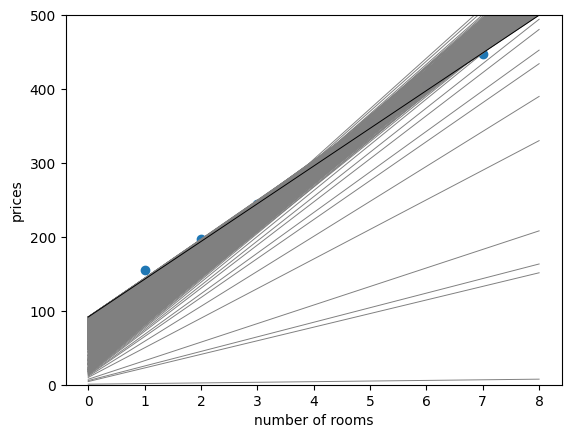

In [7]:
random.seed(0)

def lr(features,labels,learning_rate=0.01,epochs=1000):
    price_per_room=random.random()
    base_price=random.random()
    for epoch in range(epochs):
        if True:
            draw_line(price_per_room,base_price,starting=0,ending=8)
        i=random.randint(0,len(features)-1)
        num_rooms=features[i]
        price=labels[i]
        price_per_room,base_price=sqrtrick(base_price,price_per_room,num_rooms,price,learning_rate=learning_rate)
        #price_per_room,base_price=abstrick(base_price,price_per_room,num_rooms,price,learning_rate=learning_rate)
    draw_line(price_per_room, base_price, 'black', starting=0, ending=8)
    plot_points(features, labels)
    print('Price per room:', price_per_room)
    print('Base price:', base_price)
    return price_per_room, base_price
plt.ylim(0,500)

lr(features, labels, learning_rate = 0.01, epochs = 1000)